# Proyecto PRASS: Seguimiento al COVID-19

**Especialización en Analítica y Ciencia de Datos — Fundamentos de Ciencia de Datos**

Autor: Jabes Monroy

Este cuaderno desarrolla, de forma reproducible, el análisis del conjunto de datos de seguimiento del programa PRASS (Pruebas, Rastreo y Aislamiento Selectivo Sostenible). Se trabaja como entregable único: cada decisión metodológica se justifica de manera breve. Las funciones reutilizables se centralizan en el módulo `utils.py`, que este cuaderno importa.

**Estructura:** Parte I — observación y exploración del dato; Parte II — preprocesamiento.

## 1. Naturaleza de los datos

La base recoge el **seguimiento epidemiológico de casos COVID-19** realizado bajo el programa PRASS en Colombia. Cada registro resume, para una combinación de fuente, fecha, territorio (departamento y municipio) y entidad reportante, el número de casos y cuántos de ellos recibieron o no seguimiento. La granularidad es, por tanto, un dato agregado por grupo y no por individuo. La extracción tiene una fecha de corte única (25 de mayo de 2022).

**Fuente:** Portal de Datos Abiertos de Colombia (datos.gov.co), conjunto de datos identificado como `r6r5-w84k`. Archivo descargado de https://www.datos.gov.co/api/views/r6r5-w84k/rows.csv?accessType=DOWNLOAD

**Qué se espera observar.** Como instrumento de vigilancia, se anticipa que la mayoría de los grupos correspondan a pocos casos (distribución asimétrica), con una cobertura de seguimiento variable entre territorios y entidades. El interés analítico está en cuantificar esa cobertura, identificar brechas (grupos con alta proporción sin seguimiento) y comparar fuentes y entidades territoriales.

**Diccionario de variables (12).**

| Variable | Contenido |
|----------|-----------|
| `Fuente` | Origen del registro: `CONFIRMADOS`, `SOSPECHOSOS SIVIGILA` o `POBLACIÓN NO AFILIADA`. |
| `FechaRegistro` | Fecha de registro del caso (formato `MM/DD/AAAA`; la hora es constante). |
| `FechaRegistroSemana` | Semana epidemiológica del registro. |
| `Departamento` | Entidad territorial departamental, en formato `código DIVIPOLA - nombre`. |
| `Municipio` | Municipio, en formato `código DIVIPOLA - nombre`. |
| `EntidadRegistro` | Entidad (EPS, aseguradora o institución) que reporta el seguimiento. |
| `NumeroCasos` | Total de casos del grupo. |
| `NumeroCasosSinSeguimiento` | Casos del grupo sin seguimiento PRASS. |
| `NumeroCasosConSeguimiento` | Casos del grupo con seguimiento PRASS. |
| `PorcentajeCasosSinSeguimiento` | Proporción sin seguimiento (escala inconsistente; ver sección 10). |
| `PorcentajeCasosConSeguimiento` | Proporción con seguimiento (escala inconsistente; ver sección 10). |
| `FechaCorte` | Fecha de corte de la extracción (constante). |

A continuación se cargan los datos y se examina su estructura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import utils

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = utils.cargar_datos()
df.shape

(339646, 12)

La carga se realiza con `utils.cargar_datos`, que emplea el lector por defecto de pandas. Este respeta el entrecomillado de campos (norma RFC 4180), relevante porque algunos territorios contienen comas dentro del nombre, por ejemplo `"11001 - BOGOTÁ, D.C."`; al estar entrecomillados, dichas comas no fragmentan las columnas y no se produce desalineación. El conjunto tiene 339.646 registros y 12 variables.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 339646 entries, 0 to 339645
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   Fuente                         339646 non-null  str   
 1   FechaRegistro                  339646 non-null  str   
 2   FechaRegistroSemana            339646 non-null  int64 
 3   Departamento                   339646 non-null  str   
 4   Municipio                      339646 non-null  str   
 5   EntidadRegistro                339646 non-null  str   
 6   NumeroCasos                    339646 non-null  int64 
 7   NumeroCasosSinSeguimiento      339646 non-null  int64 
 8   NumeroCasosConSeguimiento      339646 non-null  int64 
 9   PorcentajeCasosSinSeguimiento  339646 non-null  str   
 10  PorcentajeCasosConSeguimiento  339646 non-null  object
 11  FechaCorte                     339646 non-null  str   
dtypes: int64(4), object(1), str(7)
memory usage: 31.1+ MB


In [3]:
df.head()

,Fuente,FechaRegistro,FechaRegistroSemana,Departamento,Municipio,EntidadRegistro,NumeroCasos,NumeroCasosSinSeguimiento,NumeroCasosConSeguimiento,PorcentajeCasosSinSeguimiento,PorcentajeCasosConSeguimiento,FechaCorte
0,CONFIRMADOS,07/03/2021 12:00:00 AM,26,41 - HUILA,41551 - PITALITO,MEDIMAS EPS SAS,1,0,1,0,10000000000000000000000,2022-05-25
1,CONFIRMADOS,05/18/2021 12:00:00 AM,20,94 - GUAINÍA,94001 - INÍRIDA,COOSALUD,9,0,9,0,10000000000000000000000,2022-05-25
2,CONFIRMADOS,05/19/2021 12:00:00 AM,20,25 - CUNDINAMARCA,25269 - FACATATIVÁ,E.P.S. SANITAS S.A.,26,1,25,384615384615384000000,9615384615384610000000,2022-05-25
3,CONFIRMADOS,01/07/2021 12:00:00 AM,1,47 - MAGDALENA,47001 - SANTA MARTA,POLICIA NACIONAL,15,0,15,0,10000000000000000000000,2022-05-25
4,CONFIRMADOS,05/02/2021 12:00:00 AM,18,68 - SANTANDER,68524 - PALMAS DEL SOCORRO,COMPARTA EPS-S,1,0,1,0,10000000000000000000000,2022-05-25


## 2. Estadísticos descriptivos

Se resume la posición y dispersión de las variables, distinguiendo numéricas y categóricas, como referencia para las secciones posteriores.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FechaRegistroSemana,339646.0,16.523595,12.721912,1.0,5.0,15.0,22.0,53.0
NumeroCasos,339646.0,10.400102,135.745747,1.0,1.0,2.0,4.0,31654.0
NumeroCasosSinSeguimiento,339646.0,0.583505,8.625612,0.0,0.0,0.0,0.0,2519.0
NumeroCasosConSeguimiento,339646.0,9.816597,131.540808,0.0,1.0,1.0,4.0,31654.0


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Fuente,339646,3,CONFIRMADOS,300309
FechaRegistro,339646,428,06/28/2021 12:00:00 AM,7878
Departamento,339646,33,05 - ANTIOQUIA,40027
Municipio,339646,1121,"11001 - BOGOTÁ, D.C.",7032
EntidadRegistro,339646,68,NUEVA EPS S.A.,54641
PorcentajeCasosSinSeguimiento,339646,2625,0,295586
PorcentajeCasosConSeguimiento,339646,2832,10000000000000000000000,284468
FechaCorte,339646,1,2022-05-25,339646


Las variables de conteo muestran medias muy superiores a sus medianas, primer indicio de asimetría positiva. En las categóricas, la columna con valor más frecuente y su frecuencia (`top`, `freq`) anticipan los desbalances que se detallan en la sección 5.

## 3. Identificación de datos faltantes (missing data)

Se cuantifica la ausencia de información por variable, en valor absoluto y porcentaje, como paso previo a cualquier decisión de imputación.

In [6]:
faltantes = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct': (df.isna().mean() * 100).round(2),
})
faltantes

,nulos,pct
Fuente,0,0.0
FechaRegistro,0,0.0
FechaRegistroSemana,0,0.0
Departamento,0,0.0
Municipio,0,0.0
EntidadRegistro,0,0.0
NumeroCasos,0,0.0
NumeroCasosSinSeguimiento,0,0.0
NumeroCasosConSeguimiento,0,0.0
PorcentajeCasosSinSeguimiento,0,0.0


No se observan valores faltantes en ninguna variable. En consecuencia, no se requiere imputación y el conjunto está completo en su forma cruda.

## 4. Registros duplicados

Se verifica la existencia de filas completamente repetidas, que podrían inflar los conteos o introducir sesgos en análisis posteriores.

In [7]:
n_dup = int(df.duplicated().sum())
print(f'Filas duplicadas (todas las columnas): {n_dup} ({n_dup / len(df):.2%})')
df[df.duplicated(keep=False)].head()

Filas duplicadas (todas las columnas): 0 (0.00%)


,Fuente,FechaRegistro,FechaRegistroSemana,Departamento,Municipio,EntidadRegistro,NumeroCasos,NumeroCasosSinSeguimiento,NumeroCasosConSeguimiento,PorcentajeCasosSinSeguimiento,PorcentajeCasosConSeguimiento,FechaCorte


Dado que cada fila es un agregado por fuente, fecha, territorio y entidad, un duplicado exacto implicaría un registro repetido. Se reporta su número para decidir, en la fase de limpieza, si corresponde consolidarlos.

## 5. Unicidad de valores y categorías distintas

Se examina la cardinalidad de cada variable y la distribución de frecuencias de las principales variables categóricas, para comprender su granularidad y posibles desbalances.

In [8]:
df.nunique().sort_values()

FechaCorte                          1
Fuente                              3
Departamento                       33
FechaRegistroSemana                53
EntidadRegistro                    68
NumeroCasosSinSeguimiento         243
FechaRegistro                     428
NumeroCasosConSeguimiento        1059
NumeroCasos                      1085
Municipio                        1121
PorcentajeCasosSinSeguimiento    2625
PorcentajeCasosConSeguimiento    2832
dtype: int64

In [9]:
for c in ['Fuente', 'Departamento', 'EntidadRegistro']:
    print(f'{c}: {df[c].nunique()} categorías distintas')

df['Fuente'].value_counts()

Fuente: 3 categorías distintas
Departamento: 33 categorías distintas
EntidadRegistro: 68 categorías distintas


Fuente
CONFIRMADOS              300309
SOSPECHOSOS SIVIGILA      32608
POBLACIÓN NO AFILIADA      6729
Name: count, dtype: int64

In [10]:
df['Departamento'].value_counts().head(10)

Departamento
05 - ANTIOQUIA             40027
25 - CUNDINAMARCA          38753
76 - VALLE DEL CAUCA       27680
68 - SANTANDER             20469
15 - BOYACÁ                19204
08 - ATLÁNTICO             19010
52 - NARIÑO                13118
73 - TOLIMA                11554
54 - NORTE DE SANTANDER    10873
41 - HUILA                 10767
Name: count, dtype: int64

La variable `Fuente` presenta tres categorías, con predominio de los casos confirmados. `Departamento` agrupa 33 entidades territoriales y `Municipio` supera el millar de valores. Tanto `Departamento` como `Municipio` codifican conjuntamente el código DIVIPOLA y el nombre en un único campo (formato `código - NOMBRE`), lo que sugiere separarlos en la fase de limpieza.

## 6. Inconsistencias en variables de texto

Antes de tratar las categóricas como factores, se revisan irregularidades tipográficas (espacios al borde y espacios dobles internos) que harían que una misma categoría se cuente como varias.

In [11]:
cat = ['Fuente', 'Departamento', 'Municipio', 'EntidadRegistro']
reporte = []
for c in cat:
    s = df[c].astype(str)
    norm = s.str.strip().str.replace(r'\s+', ' ', regex=True)
    reporte.append({
        'variable': c,
        'espacios_borde': int((s != s.str.strip()).sum()),
        'espacios_dobles': int(s.str.contains(r'  ', regex=False).sum()),
        'unicos': s.nunique(),
        'unicos_norm': norm.nunique(),
    })
pd.DataFrame(reporte)

,variable,espacios_borde,espacios_dobles,unicos,unicos_norm
0,Fuente,0,0,3,3
1,Departamento,0,0,33,33
2,Municipio,0,0,1121,1121
3,EntidadRegistro,0,58396,68,68


Se detectan espacios dobles internos en `EntidadRegistro` (por ejemplo, `E.P.S. SANITAS  S.A.`). Cuando `unicos` y `unicos_norm` coinciden, la normalización no fusiona categorías distintas; aun así, conviene estandarizar los espacios en la limpieza para asegurar agrupaciones consistentes.

## 7. Variables con desviación estándar igual a cero

Una variable constante (desviación estándar nula o un único valor) no aporta información discriminante y es candidata a ser descartada.

In [12]:
constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print('Columnas constantes:', constantes)
df.select_dtypes('number').std(numeric_only=True)

Columnas constantes: ['FechaCorte']


FechaRegistroSemana           12.721912
NumeroCasos                  135.745747
NumeroCasosSinSeguimiento      8.625612
NumeroCasosConSeguimiento    131.540808
dtype: float64

La variable `FechaCorte` es constante (`2022-05-25`): corresponde a la fecha única de extracción del reporte y no varía entre registros, por lo que no aporta información y se propone eliminarla. Ninguna variable numérica de conteo presenta desviación estándar nula.

## 8. Identificación de valores atípicos (outliers)

Se analizan las variables de conteo mediante el método del rango intercuartílico (IQR), visualizado con diagramas de caja. Se consideran atípicos los valores fuera del intervalo [Q1 - 1.5·IQR, Q3 + 1.5·IQR].

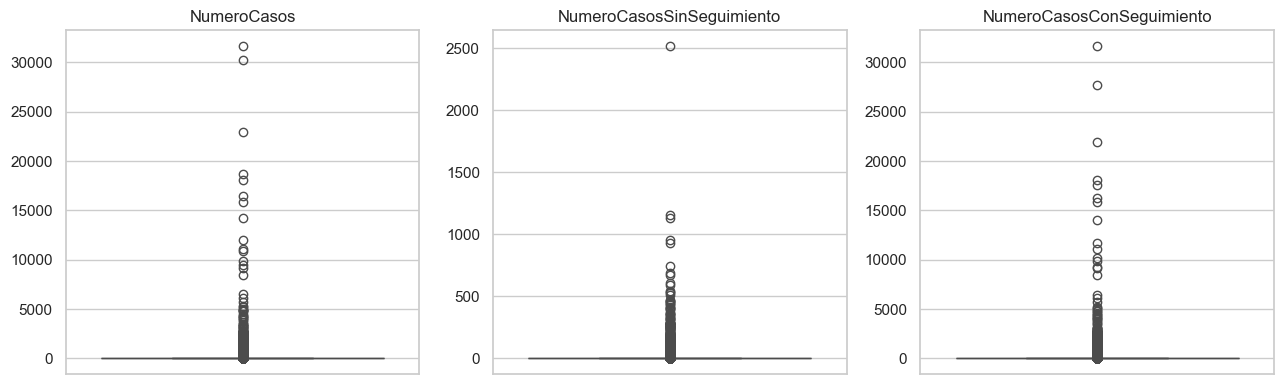

In [13]:
num = ['NumeroCasos', 'NumeroCasosSinSeguimiento', 'NumeroCasosConSeguimiento']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, num):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [14]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((s < bajo) | (s > alto)).sum())
    return {'Q1': q1, 'Q3': q3, 'max': s.max(), 'outliers': n, 'pct': round(n / len(s) * 100, 2)}

pd.DataFrame({c: iqr_outliers(df[c]) for c in num}).T

,Q1,Q3,max,outliers,pct
NumeroCasos,1.0,4.0,31654.0,46532.0,13.70
NumeroCasosSinSeguimiento,0.0,0.0,2519.0,44060.0,12.97
NumeroCasosConSeguimiento,1.0,4.0,31654.0,43767.0,12.89


Cerca del 13 % de los registros se clasifican como atípicos por IQR. No obstante, la mediana de casos es muy baja (entre 1 y 2) y el máximo alcanza 31.654, lo que evidencia una distribución fuertemente asimétrica y de cola larga, propia de datos de conteo. Por tanto, estos valores no constituyen errores de captura sino la naturaleza sesgada del fenómeno; se documentan, pero no se eliminan sin un criterio adicional.

## 9. Coherencia interna de los conteos

Se valida una identidad que el dato debe cumplir por construcción: el total de casos debe igualar la suma de los casos con y sin seguimiento.

In [15]:
suma = df['NumeroCasosConSeguimiento'] + df['NumeroCasosSinSeguimiento']
incoherentes = int((suma != df['NumeroCasos']).sum())
print(f'Registros donde Con + Sin != Total: {incoherentes} ({incoherentes / len(df):.2%})')

Registros donde Con + Sin != Total: 0 (0.00%)


La identidad `NumeroCasos = ConSeguimiento + SinSeguimiento` se cumple en la totalidad de los registros. Esto respalda la integridad de las variables de conteo y justifica recalcular los porcentajes a partir de ellas (sección 10).

## 10. Calidad de las variables de porcentaje

Se inspeccionan las columnas de porcentaje, reportadas en una escala inconsistente.

In [16]:
df[['NumeroCasos', 'NumeroCasosConSeguimiento',
    'PorcentajeCasosSinSeguimiento', 'PorcentajeCasosConSeguimiento']].head()

,NumeroCasos,NumeroCasosConSeguimiento,PorcentajeCasosSinSeguimiento,PorcentajeCasosConSeguimiento
0,1,1,0,10000000000000000000000
1,9,9,0,10000000000000000000000
2,26,25,384615384615384000000,9615384615384610000000
3,15,15,0,10000000000000000000000
4,1,1,0,10000000000000000000000


In [17]:
# Recálculo del porcentaje a partir de los conteos
pct_recalc = (df['NumeroCasosConSeguimiento'] / df['NumeroCasos'] * 100)
pct_recalc.describe()

count    339646.000000
mean         91.949712
std          25.150958
min           0.000000
25%         100.000000
50%         100.000000
75%         100.000000
max         100.000000
dtype: float64

Las columnas `PorcentajeCasos*` están corruptas: el valor 100 % aparece codificado como `1e22` y, en otros registros, como decimales, por una pérdida inconsistente del separador decimal. Dado que las variables de conteo son consistentes (sección 9), se decide **no utilizar dichas columnas** y recalcular la cobertura directamente como `NumeroCasosConSeguimiento / NumeroCasos`. El recálculo arroja un rango coherente [0, 100].

## 11. Test de Little (MCAR)

El test de Little evalúa si los datos faltantes siguen un mecanismo completamente aleatorio (MCAR). Su aplicación exige la presencia de valores ausentes. Como se estableció en la sección 3, el conjunto no presenta datos faltantes; por consiguiente, el test **no es aplicable** en esta etapa. De introducirse faltantes tras la limpieza (por ejemplo, al invalidar registros inconsistentes), se retomará su evaluación.

## 12. Síntesis de la exploración

Hallazgos de la Parte I:

- El conjunto tiene 339.646 registros y 12 variables, sin valores faltantes ni duplicados.
- No existe desalineación de columnas: las comas internas están entrecomilladas.
- La identidad de conteos (total = con + sin seguimiento) se cumple en todos los registros.
- `FechaCorte` es constante y será eliminada por no aportar información.
- `Departamento` y `Municipio` combinan código y nombre; conviene separarlos.
- `FechaRegistro` requiere conversión a tipo fecha.
- `EntidadRegistro` presenta espacios dobles que conviene estandarizar.
- Las variables de porcentaje están corruptas y se recalcularán desde los conteos.
- La distribución de casos es asimétrica; los atípicos reflejan el fenómeno, no errores.

Estos hallazgos definen las transformaciones de la Parte II.

# Parte II — Preprocesamiento

Se aplican las transformaciones derivadas de la exploración. Las funciones se centralizan en `utils.py` y se invocan paso a paso, justificando cada decisión. Se parte de una copia del dato crudo para preservar el original.

### 13. Tipado de la fecha de registro

`FechaRegistro` llega como texto con una hora constante (medianoche). Se convierte a tipo fecha para habilitar análisis temporales; la componente horaria, sin información, se descarta.

In [18]:
df_prep = df.copy()
df_prep['FechaRegistro'] = utils.parsear_fecha(df_prep['FechaRegistro'])
df_prep['FechaRegistro'].describe()

count                        339646
mean     2021-06-28 05:06:06.671181
min             2020-05-04 00:00:00
25%             2021-03-16 00:00:00
50%             2021-05-21 00:00:00
75%             2021-09-28 00:00:00
max             2022-05-18 00:00:00
Name: FechaRegistro, dtype: object

### 14. Separación de código y nombre territorial

`Departamento` y `Municipio` combinan el código DIVIPOLA y el nombre. Se separan en columnas `...Codigo` y `...Nombre`, lo que facilita agrupaciones y futuros cruces con otras fuentes.

In [19]:
for col in ['Departamento', 'Municipio']:
    cn = utils.separar_codigo_nombre(df_prep[col])
    df_prep[col + 'Codigo'] = cn['codigo']
    df_prep[col + 'Nombre'] = cn['nombre']
df_prep[['DepartamentoCodigo', 'DepartamentoNombre',
         'MunicipioCodigo', 'MunicipioNombre']].head()

,DepartamentoCodigo,DepartamentoNombre,MunicipioCodigo,MunicipioNombre
0,41,HUILA,41551,PITALITO
1,94,GUAINÍA,94001,INÍRIDA
2,25,CUNDINAMARCA,25269,FACATATIVÁ
3,47,MAGDALENA,47001,SANTA MARTA
4,68,SANTANDER,68524,PALMAS DEL SOCORRO


### 15. Estandarización de texto

Se normalizan los espacios de `EntidadRegistro` (bordes y dobles internos) para asegurar agrupaciones consistentes.

In [20]:
df_prep['EntidadRegistro'] = utils.estandarizar_texto(df_prep['EntidadRegistro'])
print('Filas con espacios dobles tras estandarizar:',
      int(df_prep['EntidadRegistro'].str.contains(r'  ', regex=False).sum()))

Filas con espacios dobles tras estandarizar: 0


### 16. Recálculo de la cobertura de seguimiento

En reemplazo de las columnas de porcentaje corruptas, se calcula la cobertura (%) a partir de los conteos, ya validados como coherentes.

In [21]:
df_prep = utils.agregar_cobertura(df_prep)
df_prep[['NumeroCasos', 'NumeroCasosConSeguimiento',
         'CoberturaConSeguimiento', 'CoberturaSinSeguimiento']].head()

,NumeroCasos,NumeroCasosConSeguimiento,CoberturaConSeguimiento,CoberturaSinSeguimiento
0,1,1,100.00,0.00
1,9,9,100.00,0.00
2,26,25,96.15,3.85
3,15,15,100.00,0.00
4,1,1,100.00,0.00


### 17. Eliminación de columnas constantes o corruptas

Se descartan `FechaCorte` (constante), las dos columnas de porcentaje corruptas y los campos territoriales originales, ya sustituidos por sus versiones código/nombre.

In [22]:
df_prep = df_prep.drop(columns=[
    'FechaCorte', 'PorcentajeCasosSinSeguimiento', 'PorcentajeCasosConSeguimiento',
    'Departamento', 'Municipio',
])
df_prep.info()

<class 'pandas.DataFrame'>
RangeIndex: 339646 entries, 0 to 339645
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Fuente                     339646 non-null  str           
 1   FechaRegistro              339646 non-null  datetime64[us]
 2   FechaRegistroSemana        339646 non-null  int64         
 3   EntidadRegistro            339646 non-null  str           
 4   NumeroCasos                339646 non-null  int64         
 5   NumeroCasosSinSeguimiento  339646 non-null  int64         
 6   NumeroCasosConSeguimiento  339646 non-null  int64         
 7   DepartamentoCodigo         339646 non-null  str           
 8   DepartamentoNombre         339646 non-null  str           
 9   MunicipioCodigo            339646 non-null  str           
 10  MunicipioNombre            339646 non-null  str           
 11  CoberturaConSeguimiento    339646 non-null  float64       
 12 

### 18. Diagnóstico y conversión de tipos

Se revisa, para cada columna no numérica, si su contenido es convertible a número, distinguiendo numéricas mal tipadas de identificadores. Luego se asigna el tipo adecuado: `category` para las variables de baja cardinalidad y categoría ordinal para la semana epidemiológica.

In [23]:
utils.diagnosticar_tipos(df_prep)

,columna,dtype,convertible_a_numerico,es_identificador
0,Fuente,str,False,False
1,EntidadRegistro,str,False,False
2,DepartamentoCodigo,str,True,True
3,DepartamentoNombre,str,False,False
4,MunicipioCodigo,str,True,True
5,MunicipioNombre,str,False,False


Las únicas columnas convertibles a número que **no** deben convertirse son los códigos DIVIPOLA (`DepartamentoCodigo`, `MunicipioCodigo`): son identificadores y perderían los ceros a la izquierda. El resto de variables de texto son categóricas legítimas. En consecuencia, se tipifican como `category` (y la semana epidemiológica como categoría ordinal), sin forzar conversiones numéricas.

In [24]:
df_prep = utils.tipar_columnas(df_prep)
df_prep.dtypes

Fuente                             category
FechaRegistro                datetime64[us]
FechaRegistroSemana                category
EntidadRegistro                    category
NumeroCasos                           int64
NumeroCasosSinSeguimiento             int64
NumeroCasosConSeguimiento             int64
DepartamentoCodigo                 category
DepartamentoNombre                 category
MunicipioCodigo                    category
MunicipioNombre                    category
CoberturaConSeguimiento             float64
CoberturaSinSeguimiento             float64
dtype: object

### 19. Resultado del preprocesamiento

El DataFrame depurado `df_prep` queda tipado, con territorio descompuesto, texto estandarizado, cobertura recalculada y tipos asignados (`category` y categoría ordinal). Sirve de base para la siguiente etapa (EDA). La orquestación equivalente está disponible en `utils.preprocesar`.

In [25]:
df_prep.head()

,Fuente,FechaRegistro,FechaRegistroSemana,EntidadRegistro,NumeroCasos,NumeroCasosSinSeguimiento,NumeroCasosConSeguimiento,DepartamentoCodigo,DepartamentoNombre,MunicipioCodigo,MunicipioNombre,CoberturaConSeguimiento,CoberturaSinSeguimiento
0,CONFIRMADOS,2021-07-03,26,MEDIMAS EPS SAS,1,0,1,41,HUILA,41551,PITALITO,100.00,0.00
1,CONFIRMADOS,2021-05-18,20,COOSALUD,9,0,9,94,GUAINÍA,94001,INÍRIDA,100.00,0.00
2,CONFIRMADOS,2021-05-19,20,E.P.S. SANITAS S.A.,26,1,25,25,CUNDINAMARCA,25269,FACATATIVÁ,96.15,3.85
3,CONFIRMADOS,2021-01-07,1,POLICIA NACIONAL,15,0,15,47,MAGDALENA,47001,SANTA MARTA,100.00,0.00
4,CONFIRMADOS,2021-05-02,18,COMPARTA EPS-S,1,0,1,68,SANTANDER,68524,PALMAS DEL SOCORRO,100.00,0.00


# Parte III — Análisis exploratorio (EDA)

Sobre el dato depurado `df_prep` se exploran las distribuciones y la métrica central del estudio: la cobertura de seguimiento. El EDA se desarrolla por bloques; este primero aborda distribuciones y cobertura global.

### 20. Distribución de las variables de conteo

Por la fuerte asimetría detectada en la Parte I, las variables de conteo se visualizan en escala logarítmica (`log1p`), que comprime la cola larga y revela la forma de la distribución.

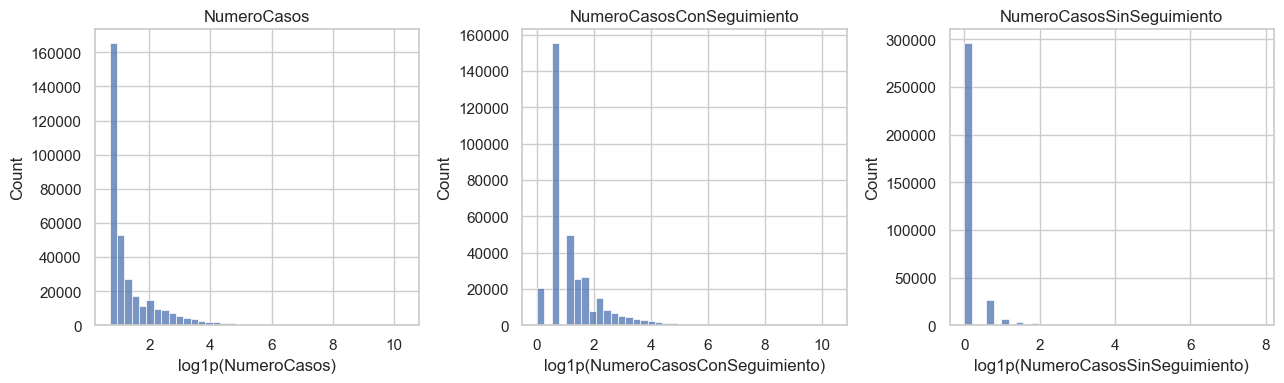

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, ['NumeroCasos', 'NumeroCasosConSeguimiento', 'NumeroCasosSinSeguimiento']):
    sns.histplot(np.log1p(df_prep[c]), bins=40, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('log1p(' + c + ')')
plt.tight_layout()
plt.show()

La mayoría de los grupos concentra pocos casos: las distribuciones decaen rápidamente incluso en escala logarítmica. `NumeroCasosSinSeguimiento` se acumula en cero, coherente con una cobertura alta en gran parte de los registros.

### 21. Distribución de la cobertura de seguimiento

Se examina la distribución de `CoberturaConSeguimiento` (%), la variable de interés recalculada desde los conteos.

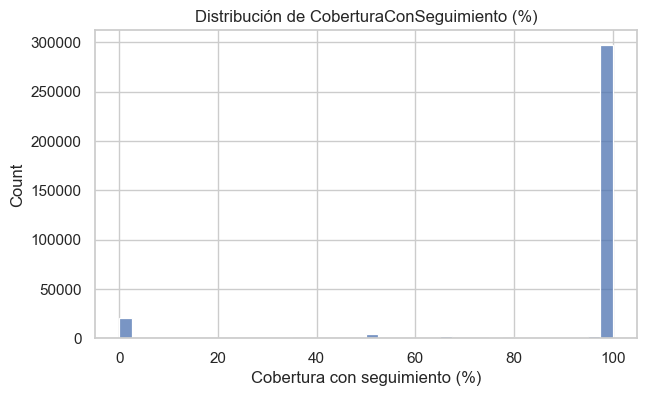

count    339646.000000
mean         91.949721
std          25.150957
min           0.000000
25%         100.000000
50%         100.000000
75%         100.000000
max         100.000000
Name: CoberturaConSeguimiento, dtype: float64

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df_prep['CoberturaConSeguimiento'], bins=40, ax=ax)
ax.set_title('Distribución de CoberturaConSeguimiento (%)')
ax.set_xlabel('Cobertura con seguimiento (%)')
plt.show()
df_prep['CoberturaConSeguimiento'].describe()

La cobertura se concentra fuertemente en el 100 %: en la mayoría de los grupos todos los casos reciben seguimiento. Existe, no obstante, una fracción de registros con cobertura parcial o nula que constituye el foco de interés (brechas).

### 22. Cobertura global ponderada por casos

El promedio simple de la cobertura por fila sobrerrepresenta a los grupos pequeños. La medida correcta de la cobertura real del sistema pondera por el número de casos: `sum(ConSeguimiento) / sum(NumeroCasos)`.

In [28]:
casos = df_prep['NumeroCasos'].sum()
con = df_prep['NumeroCasosConSeguimiento'].sum()
glob_pond = con / casos * 100
glob_simple = df_prep['CoberturaConSeguimiento'].mean()
print(f'Casos totales: {casos:,}')
print(f'Cobertura global ponderada por casos: {glob_pond:.2f}%')
print(f'Promedio simple de filas:            {glob_simple:.2f}%')

Casos totales: 3,532,353
Cobertura global ponderada por casos: 94.39%
Promedio simple de filas:            91.95%


La cobertura global ponderada difiere del promedio simple de filas, lo que confirma que esta última está sesgada por la abundancia de grupos pequeños. En adelante, las comparaciones por fuente, territorio y entidad usarán la versión ponderada por casos.

### 23. Análisis univariado de variables categóricas

Se describe la composición de las principales categóricas. `Fuente`, con tres categorías, se resume en un gráfico de torta; `Departamento` y `EntidadRegistro`, de mayor cardinalidad, mediante barras de las categorías más frecuentes.

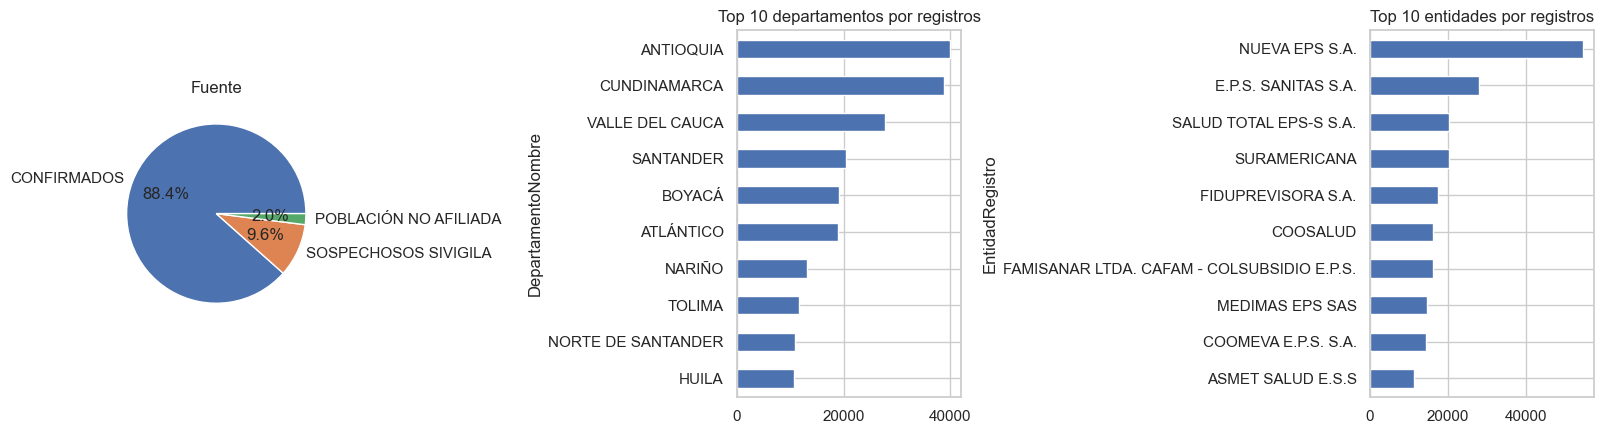

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
df_prep['Fuente'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], ylabel='')
axes[0].set_title('Fuente')
df_prep['DepartamentoNombre'].value_counts().head(10).plot.barh(ax=axes[1])
axes[1].set_title('Top 10 departamentos por registros')
axes[1].invert_yaxis()
df_prep['EntidadRegistro'].value_counts().head(10).plot.barh(ax=axes[2])
axes[2].set_title('Top 10 entidades por registros')
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

Predominan los casos `CONFIRMADOS`. Los registros se concentran en los departamentos más poblados (Antioquia, Cundinamarca, Valle) y en unas pocas entidades de gran tamaño (NUEVA EPS, Sanitas), lo que anticipa desbalances a considerar en los análisis comparativos.

### 24. Estimación de densidad (KDE)

La densidad por núcleo (KDE) complementa los histogramas mostrando la forma suavizada de la distribución de la cobertura y de los conteos (en escala logarítmica).

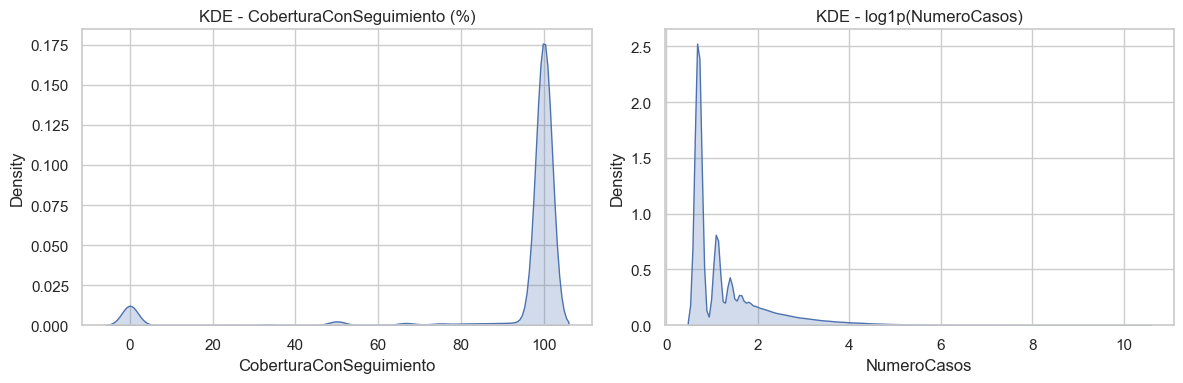

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(df_prep['CoberturaConSeguimiento'], fill=True, ax=axes[0])
axes[0].set_title('KDE - CoberturaConSeguimiento (%)')
sns.kdeplot(np.log1p(df_prep['NumeroCasos']), fill=True, ax=axes[1])
axes[1].set_title('KDE - log1p(NumeroCasos)')
plt.tight_layout()
plt.show()

La densidad confirma la fuerte concentración de la cobertura cerca del 100 % y la asimetría positiva de los conteos, que persiste aun en escala logarítmica.

## Bloque 3 — Análisis bivariado: cobertura por categoría

Se relaciona la variable objetivo (cobertura de seguimiento) con las principales categóricas. En todos los casos la cobertura se calcula **ponderada por casos** (`utils.cobertura_ponderada`), que refleja la cobertura real del sistema y no sobrerrepresenta a los grupos pequeños.

### 25. Cobertura por fuente

Comparación de la cobertura entre los tres orígenes de registro.

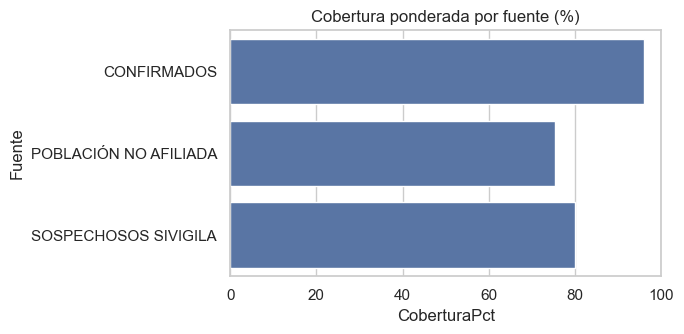

,Fuente,casos,con,CoberturaPct
0,POBLACIÓN NO AFILIADA,38311,28907,75.45
1,SOSPECHOSOS SIVIGILA,302180,241526,79.93
2,CONFIRMADOS,3191862,3063735,95.99


In [31]:
cob_fuente = utils.cobertura_ponderada(df_prep, 'Fuente')
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=cob_fuente, x='CoberturaPct', y='Fuente', ax=ax)
ax.set_title('Cobertura ponderada por fuente (%)')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()
cob_fuente

La cobertura difiere según el origen del registro, lo que sugiere que el mecanismo de captación (confirmados, sospechosos o población no afiliada) condiciona el seguimiento.

### 26. Cobertura por departamento

Se ordenan los departamentos por cobertura para identificar las mayores brechas (extremos inferior y superior).

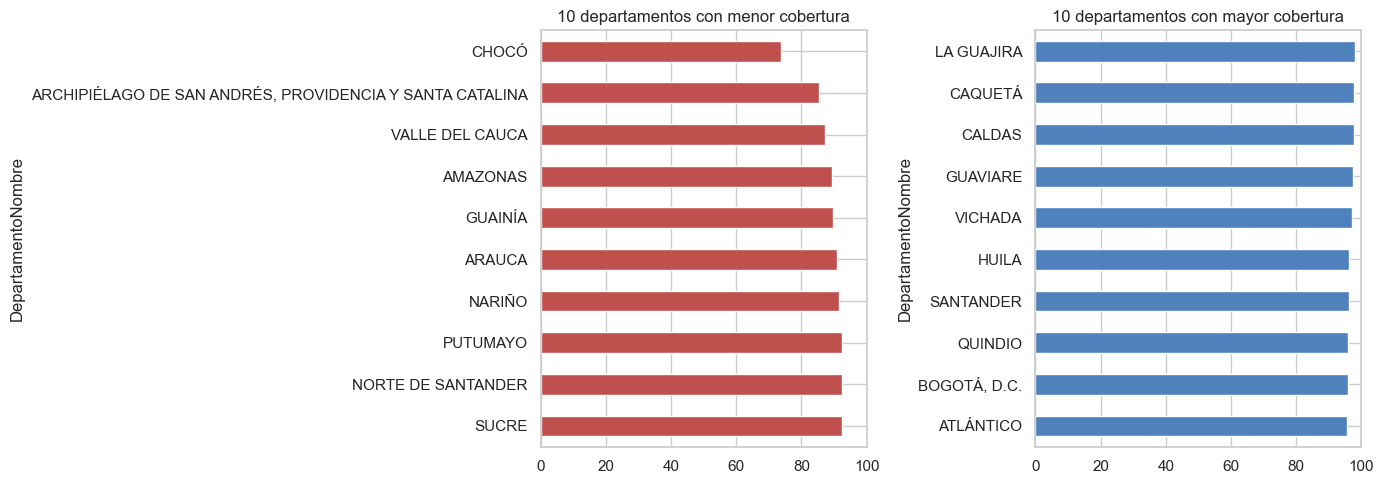

In [32]:
cob_dep = utils.cobertura_ponderada(df_prep, 'DepartamentoNombre')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cob_dep.head(10).plot.barh(x='DepartamentoNombre', y='CoberturaPct', ax=axes[0], legend=False, color='#c0504d')
axes[0].set_title('10 departamentos con menor cobertura')
axes[0].set_xlim(0, 100)
axes[0].invert_yaxis()
cob_dep.tail(10).plot.barh(x='DepartamentoNombre', y='CoberturaPct', ax=axes[1], legend=False, color='#4f81bd')
axes[1].set_title('10 departamentos con mayor cobertura')
axes[1].set_xlim(0, 100)
plt.tight_layout()
plt.show()

Existe heterogeneidad territorial: los departamentos del extremo inferior concentran las brechas de seguimiento y serían prioritarios para intervención, frente a los de cobertura cercana al 100 %.

### 27. Cobertura por entidad reportante

Para evitar el ruido de entidades con muy pocos casos, se exigen al menos 1.000 casos. Se muestran las diez entidades con menor cobertura.

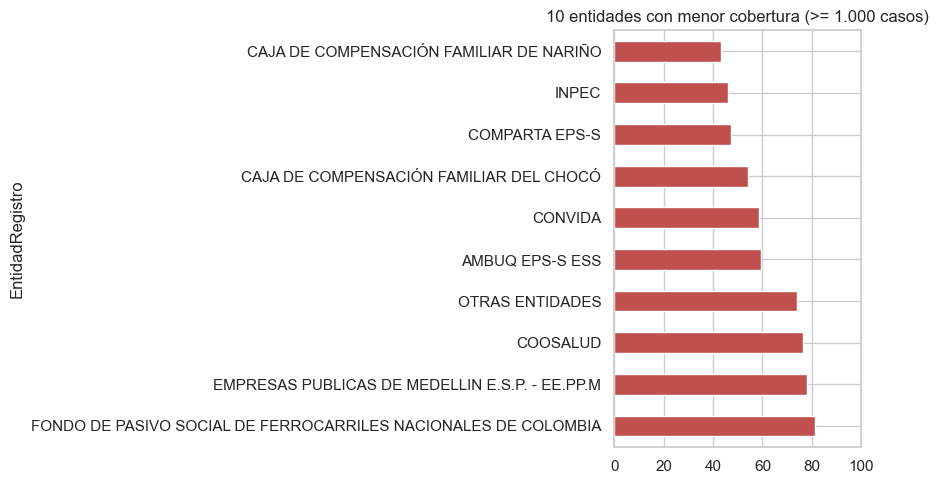

,EntidadRegistro,casos,con,CoberturaPct
0,CAJA DE COMPENSACIÓN FAMILIAR DE NARIÑO,3545,1531,43.19
1,INPEC,4103,1893,46.14
2,COMPARTA EPS-S,27507,12975,47.17
3,CAJA DE COMPENSACIÓN FAMILIAR DEL CHOCÓ,3431,1863,54.30
4,CONVIDA,17117,10053,58.73
5,AMBUQ EPS-S ESS,4878,2895,59.35
6,OTRAS ENTIDADES,39195,29007,74.01
7,COOSALUD,94775,72458,76.45
8,EMPRESAS PUBLICAS DE MEDELLIN E.S.P. - EE.PP.M,1018,793,77.90
9,FONDO DE PASIVO SOCIAL DE FERROCARRILES NACION...,2962,2407,81.26


In [33]:
cob_ent = utils.cobertura_ponderada(df_prep, 'EntidadRegistro', min_casos=1000)
fig, ax = plt.subplots(figsize=(9, 5))
cob_ent.head(10).plot.barh(x='EntidadRegistro', y='CoberturaPct', ax=ax, legend=False, color='#c0504d')
ax.set_title('10 entidades con menor cobertura (>= 1.000 casos)')
ax.set_xlim(0, 100)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
cob_ent.head(10)

La cobertura también varía entre entidades reportantes con volumen comparable, lo que apunta a diferencias en la gestión del seguimiento más allá del territorio.